# Диаграммы персистентности для фазовых вложений временных рядов

На данном этапе для каждого временного ряда используются ранее найденные оптимальные параметры фазового вложения: лаг `tau` и размерность `dimension`.  
Для каждого ряда строится облако точек в фазовом пространстве, после чего по этому облаку вычисляются диаграммы персистентности.

Расчёт диаграмм выполняется в Julia с помощью библиотеки `Ripserer.jl`, а визуализация результатов выполняется в Python.

In [9]:
import subprocess

packages = ["CSV", "DataFrames", "DelayEmbeddings", "Ripserer"]

for package in packages:
    print(f"Installing/checking {package}...")

    result = subprocess.run(
        [
            "julia",
            "--project=.",
            "-e",
            f'import Pkg; Pkg.add("{package}")'
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Ошибка при установке пакета {package}")

Installing/checking CSV...

   Resolving package versions...
     Project No packages added to or removed from `~/tda-2026/Project.toml`
    Manifest No packages added to or removed from `~/tda-2026/Manifest.toml`

Installing/checking DataFrames...


KeyboardInterrupt: 

In [10]:
import subprocess

process = subprocess.Popen(
    ["julia", "--project=.", "persistence_diagrams.jl"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(line, end="")

return_code = process.wait()

if return_code != 0:
    raise subprocess.CalledProcessError(return_code, process.args)

Reading dataset: dataset_clean.csv
Reading best embedding parameters: uzal_cost_final_result.csv
Rows in best parameters table: 26
[1/26] Lab1_Hpol
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[2/26] Lab1_dev
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[3/26] Lab1_G3_T600
[4/26] Lab1_dPmg
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[5/26] Lab1_PposleNag
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[6/26] Lab1_TC_Ptgdg
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[7/26] Lab1_G2_Fн9
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/Ripserer/f1W5D/src/filtrations/rips.jl:228
[8/26] Lab1_G3_Pc2
[9/26] Lab1_G3_T606
[10/26] Lab1_G2_2F2
┌ Warning: points not unique
└ @ Ripserer ~/.julia/packages/

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd

# Основной файл (H0/H1)
PERSISTENCE_PATH = Path("persistence_diagrams_31_columns.csv")

# Отдельно посчитанная H2-гомология
H2_PATH = Path("h2_persistence_selected_columns.csv")

diagrams_base = pd.read_csv(PERSISTENCE_PATH)
diagrams_h2 = pd.read_csv(H2_PATH)

# Берём только те колонки, которые есть в основном файле,
common_cols = [col for col in diagrams_base.columns if col in diagrams_h2.columns]

diagrams_base = diagrams_base[common_cols].copy()
diagrams_h2 = diagrams_h2[common_cols].copy()

# Объединяем H0/H1 + H2
diagrams = pd.concat(
    [diagrams_base, diagrams_h2],
    ignore_index=True
)


print("\nКоличество точек по размерностям гомологий:")
print(diagrams["homology_dimension"].value_counts().sort_index())

diagrams.head()


Количество точек по размерностям гомологий:
homology_dimension
0    29210
1    15829
2     1425
Name: count, dtype: int64


,column,tau,dimension,homology_dimension,birth,death,persistence,is_infinite
0,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
1,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
2,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
3,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
4,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False


In [12]:
print("Количество точек диаграмм:", len(diagrams))
print("Количество рядов:", diagrams["column"].nunique())

diagrams.head()

Количество точек диаграмм: 46464
Количество рядов: 31


,column,tau,dimension,homology_dimension,birth,death,persistence,is_infinite
0,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
1,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
2,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
3,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False
4,Lab1_G1_N3,3,4,0,0.0,0.213524,0.213524,False


In [13]:
import plotly.graph_objects as go


def plot_persistence_diagram_for_column(column_name):
    one = diagrams[diagrams["column"] == column_name].copy()

    # Для обычной диаграммы birth-death не отображаем бесконечные интервалы,
    # потому что death = Inf нельзя нормально положить на конечную ось.
    finite = one[
        np.isfinite(one["birth"]) &
        np.isfinite(one["death"])
    ].copy()

    if finite.empty:
        fig = go.Figure()
        fig.update_layout(
            title=f"Нет конечных точек диаграммы для ряда: {column_name}",
            width=800,
            height=650
        )
        fig.show()
        return

    max_value = max(finite["birth"].max(), finite["death"].max())
    min_value = min(finite["birth"].min(), finite["death"].min())

    padding = 0.05 * (max_value - min_value) if max_value > min_value else 1.0
    axis_min = min_value - padding
    axis_max = max_value + padding

    fig = go.Figure()

    for h_dim in sorted(finite["homology_dimension"].unique()):
        part = finite[finite["homology_dimension"] == h_dim]

        fig.add_trace(
            go.Scatter(
                x=part["birth"],
                y=part["death"],
                mode="markers",
                name=f"H{h_dim}",
                customdata=np.stack(
                    [
                        part["persistence"],
                        part["tau"],
                        part["dimension"]
                    ],
                    axis=-1
                ),
                hovertemplate=(
                    "birth = %{x:.4f}<br>"
                    "death = %{y:.4f}<br>"
                    "persistence = %{customdata[0]:.4f}<br>"
                    "tau = %{customdata[1]}<br>"
                    "dimension = %{customdata[2]}<extra></extra>"
                )
            )
        )

    # Диагональ birth = death
    fig.add_trace(
        go.Scatter(
            x=[axis_min, axis_max],
            y=[axis_min, axis_max],
            mode="lines",
            name="birth = death",
            line=dict(dash="dash")
        )
    )

    tau_value = int(one["tau"].iloc[0])
    dimension_value = int(one["dimension"].iloc[0])

    infinite_count = one["is_infinite"].sum() if "is_infinite" in one.columns else 0

    fig.update_layout(
        title=(
            f"Диаграмма персистентности для ряда: {column_name}<br>"
            f"tau = {tau_value}, dimension = {dimension_value}, "
            f"бесконечных интервалов: {infinite_count}"
        ),
        xaxis_title="Birth",
        yaxis_title="Death",
        width=850,
        height=700,
        legend_title="Гомологии"
    )

    fig.update_xaxes(range=[axis_min, axis_max])
    fig.update_yaxes(range=[axis_min, axis_max], scaleanchor="x", scaleratio=1)

    fig.show()

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

columns = sorted(diagrams["column"].dropna().unique())

column_dropdown = widgets.Dropdown(
    options=columns,
    value=columns[0],
    description="Ряд:",
    layout=widgets.Layout(width="700px")
)

output = widgets.Output()


def on_column_change(change):
    if change["name"] == "value":
        with output:
            clear_output(wait=True)
            plot_persistence_diagram_for_column(change["new"])


column_dropdown.observe(on_column_change)

display(column_dropdown)

with output:
    plot_persistence_diagram_for_column(column_dropdown.value)

display(output)

Dropdown(description='Ряд:', layout=Layout(width='700px'), options=('Lab1_G1_N1', 'Lab1_G1_N2', 'Lab1_G1_N3', …

Output()

## Все диграммы

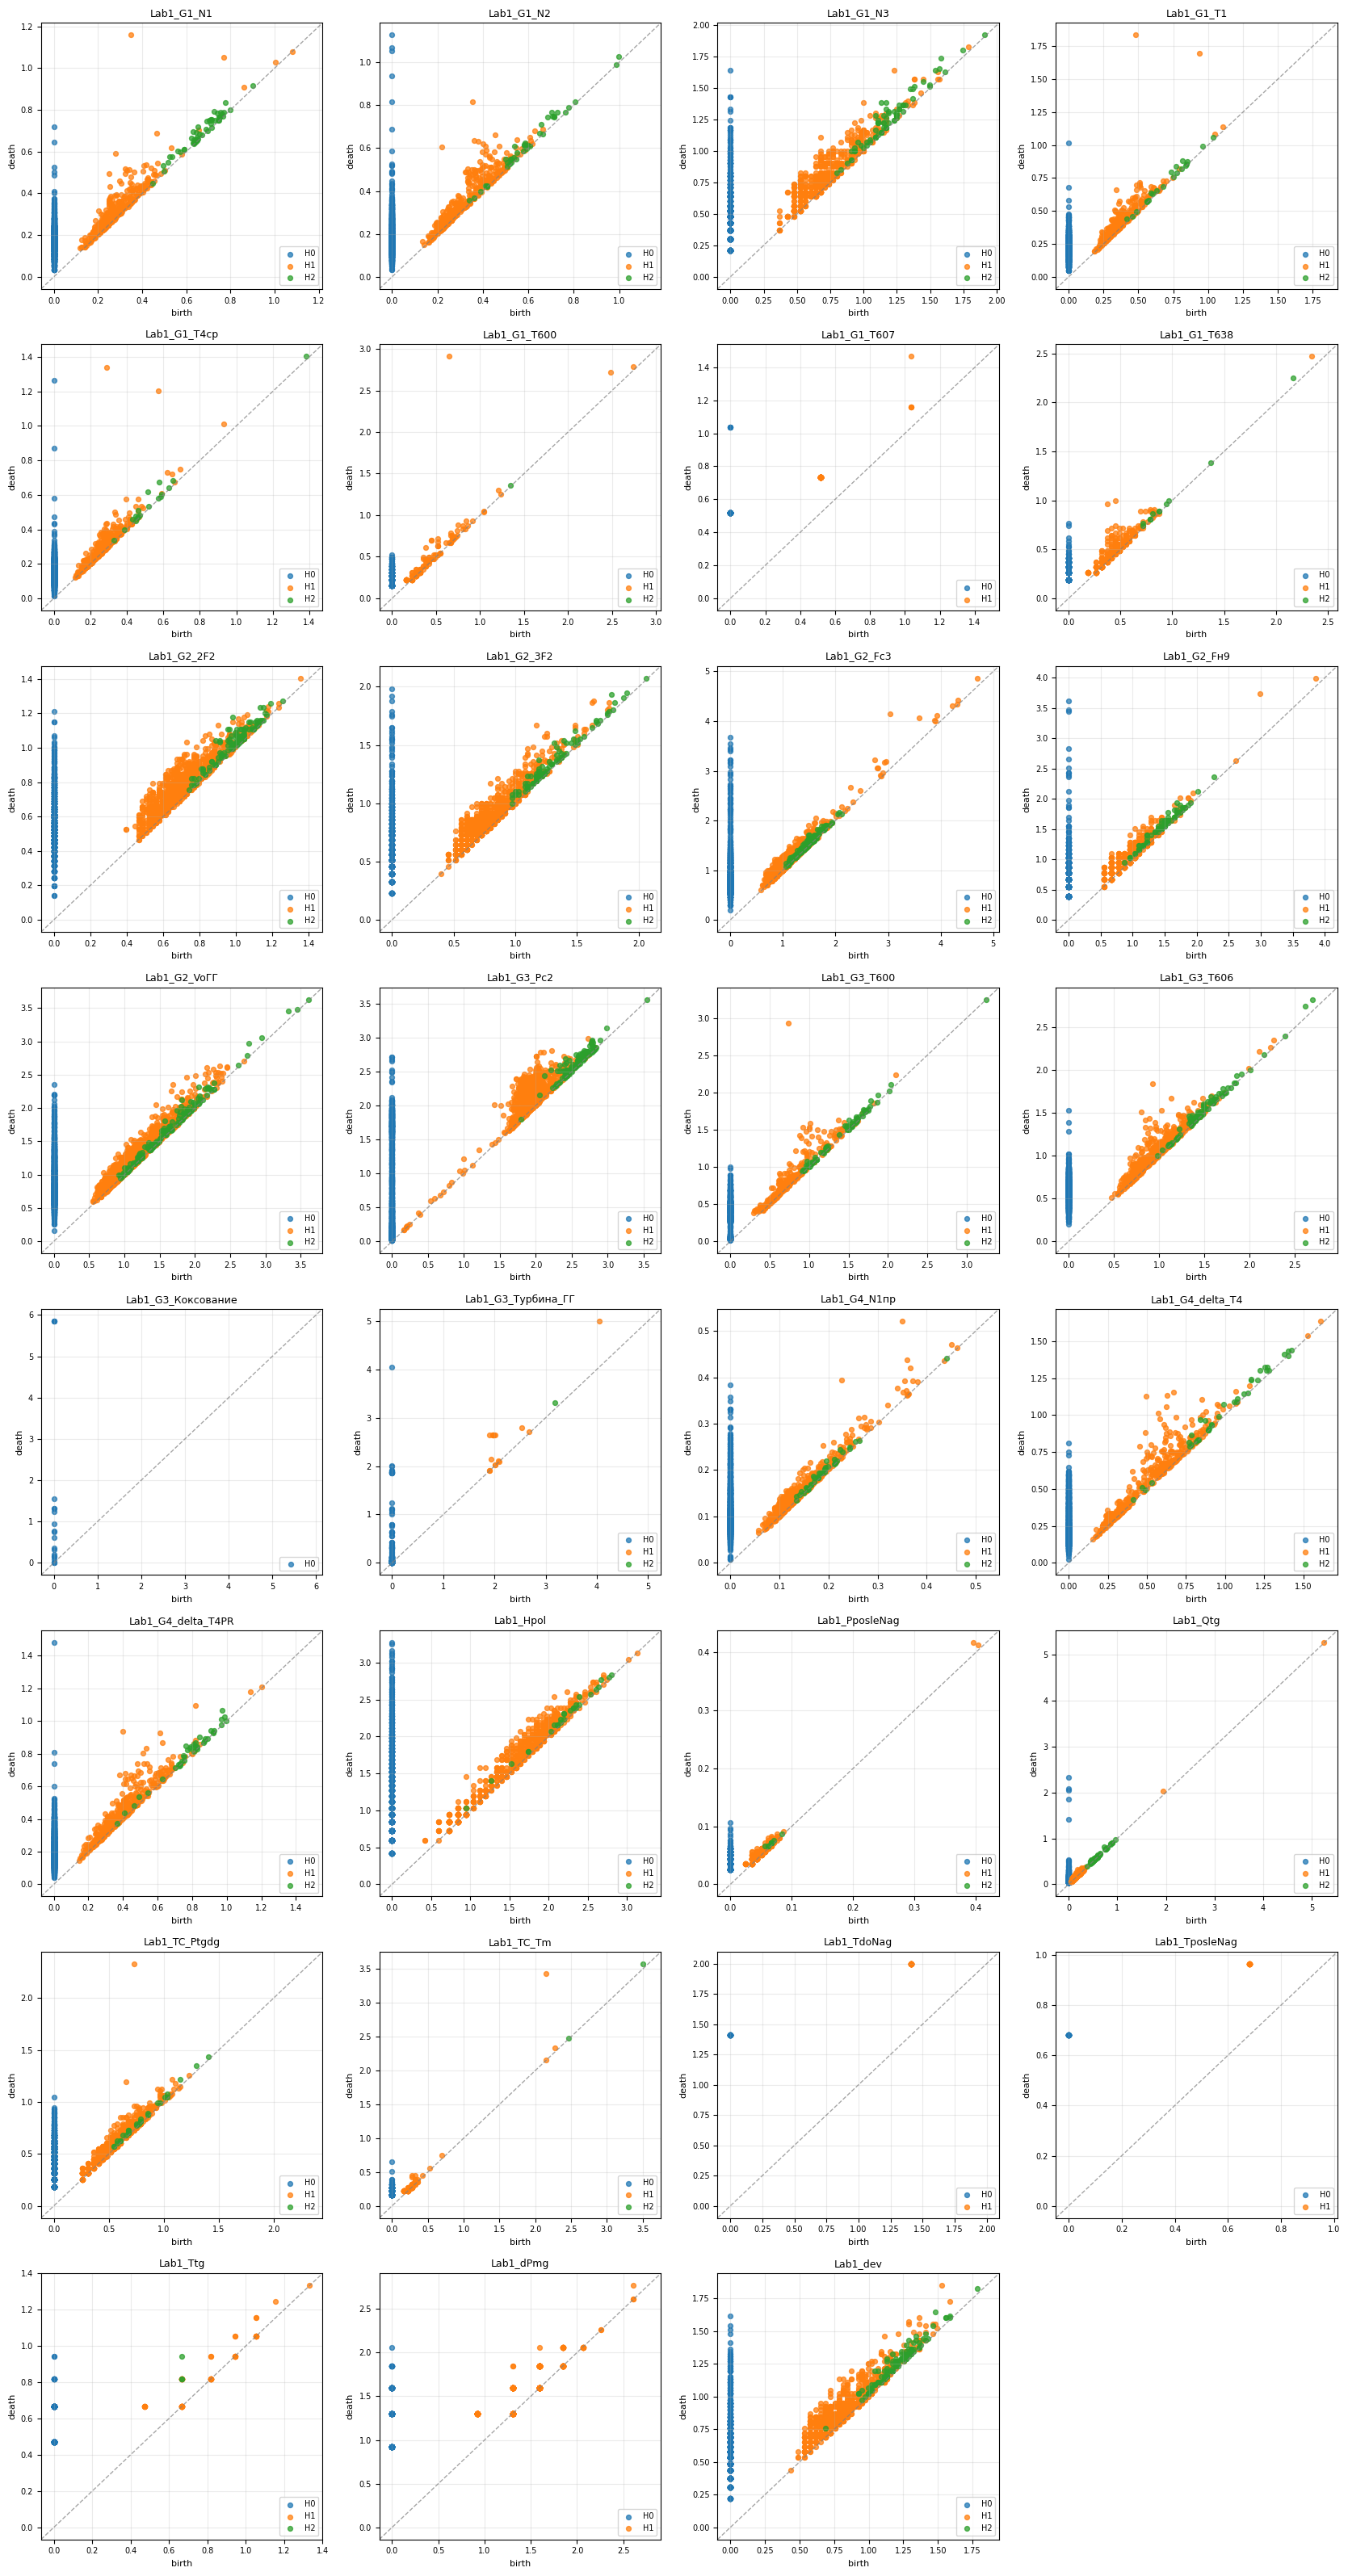

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Все ряды, для которых есть диаграммы
columns = sorted(diagrams["column"].dropna().unique())

# Настройки сетки
plots_per_row = 4
n_cols = plots_per_row
n_rows = math.ceil(len(columns) / plots_per_row)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 4.0 * n_rows),
    squeeze=False
)

# Цвета для разных размерностей гомологий
homology_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
}

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    part = diagrams[diagrams["column"] == column_name].copy()

    # Убираем бесконечные интервалы для визуализации
    part = part[
        np.isfinite(part["birth"])
        & np.isfinite(part["death"])
        & (part["death"] > part["birth"])
    ]

    if part.empty:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5,
            0.5,
            "Нет конечных точек",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=9,
        )
        ax.set_axis_off()
        continue

    min_val = min(part["birth"].min(), part["death"].min())
    max_val = max(part["birth"].max(), part["death"].max())

    padding = 0.05 * (max_val - min_val) if max_val > min_val else 1.0
    x_min = min_val - padding
    x_max = max_val + padding

    # Диагональ death = birth
    ax.plot(
        [x_min, x_max],
        [x_min, x_max],
        linestyle="--",
        linewidth=1,
        color="gray",
        alpha=0.7,
    )

    # Точки диаграммы по размерностям гомологий
    for h_dim in sorted(part["homology_dimension"].dropna().unique()):
        h_part = part[part["homology_dimension"] == h_dim]

        ax.scatter(
            h_part["birth"],
            h_part["death"],
            s=18,
            alpha=0.75,
            label=f"H{int(h_dim)}",
            color=homology_colors.get(int(h_dim), None),
        )

    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("birth", fontsize=8)
    ax.set_ylabel("death", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(x_min, x_max)
    ax.grid(alpha=0.25)

    # Легенду лучше оставить маленькой
    ax.legend(fontsize=7, loc="lower right")

# Убираем пустые оси, если число графиков не кратно 4
for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].set_axis_off()

plt.tight_layout()

# Можно сохранить в файл
plt.savefig("all_persistence_diagrams_grid.png", dpi=300, bbox_inches="tight")

plt.show()